#5장
pre-trained

##GPT 모델 초기화

In [ ]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M={
    "vocab_size":50257, #vocabulary size(총 50257개의 token사용)
    "context_length":256, #입력 token의 최대 개수가 256개이다.
    "emb_dim":768,  #embedding vector의 차원 수가 768차원이다.
    "n_heads":12 ,  #attention head의 개수가 12
    "n_layers":12,  #transformer의 개수가 12
    "drop_rate":0.1,  #dropout rate가 0.1
    "qkv_bias":False
}
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M) #GPTModel 초기화
model.eval()


#text to tokenID함수와 tokenID to text함수를 구현

In [24]:
import tiktoken
from previous_chapters import generate_text_simple

#text를 tokenID로 변환
def text_to_token_ids(text,tokenizer):
  #tokenizer를 이용하여 text를 tokenization한다.
  encoded=tokenizer.encode(text,allowed_special={'<|endoftext|>'})
  #tokenization된 것을 배치 차원을 추가하여 tensor형태로 변환시켜준다.
  encoded_tensor=torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

#tokenID를 text로 변환
def token_ids_to_text(token_ids,tokenizer):
  #배치 차원을 제거한다.
  flat=token_ids.squeeze(0)
  #tokenizer를 이용하여 tokenID를 text화한다.
  return tokenizer.decode(flat.tolist())

start_context="Every effort moves you"
tokenizer=tiktoken.get_encoding("gpt2")

#아직 학습되지 않은 model을 이용하여 다음 단어를 예측하는 형식으로 텍스트를 생성한다.
#즉 Every effort moves you가 입력되었을 때 you 다음에 어떤 단어가 오는 지를 예측하여 문장을 완성시킨다.
token_ids=generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("출력 텍스트:\n",token_ids_to_text(token_ids,tokenizer))

출력 텍스트:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


#LLM이 입력 text를 받아 text를 생성하는 흐름

In [25]:
#text와 이와 매핑되는 각각의 tokenID
inputs=torch.tensor([[16833,3626,6100],   #every effort moves
                     [40,1107,558]])      #I really like

targets=torch.tensor([[3626,6100,345],    #effort moves you
                      [1107,588,11311]])  #really like chocolate

In [26]:
#inputs을 모델에 넣고, 2개의 행 각각의 로짓 벡터를 계산한다.
#이때 로짓 벡터란 vocabulary내 token들의 다음 단어로 예측되는 확률 벡터이다.
with torch.no_grad(): #아직 훈련하지 않기 때문에 gradient 추적은 끈다.
  logits=model(inputs)

probas=torch.softmax(logits,dim=-1)
print(probas.shape)

#torch.Size([2, 3, 50257])
#2개의 샘플(행)
#각 행에 있는 token개수 3
#vocabulary size

torch.Size([2, 3, 50257])


In [27]:
#확률 점수에 argmax 함수를 적용해 tokenID를 추출
#argmax함수는 주어진 NumPy 배열에서 가장 높은 값을 가진 값의 인덱스를 반환하는 함수이다.
token_ids=torch.argmax(probas,dim=-1,keepdim=True)
print("토큰 ID: \n",token_ids)

토큰 ID: 
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [31756]]])


In [28]:
#tokenID를 text로 변환한다.
print(f"첫 번째 샘플의 타깃: {token_ids_to_text(targets[0],tokenizer)}")
print(f"두 번째 샘플의 출력:"
      f" {token_ids_to_text(token_ids[0].flatten(),tokenizer)}")

첫 번째 샘플의 타깃:  effort moves you
두 번째 샘플의 출력:  Armed heNetflix


#loss을 사용해 model이 생성한 text의 성능을 정량적으로 평가
##이 함수를 사용해 생성 text의 품질을 높이도록 모델 가중치를 업데이트한다.

In [29]:
#목적은 정답 target tokenID에 해당하는 index의 softmax 확률을 증가시키는 것이다.

#2개의 입력 text에 대해 target token에 해당하는 초기 softmax 확률 점수를 각각 출력할 수 있다.
text_idx=0
target_probas_1=probas[text_idx,[0,1,2],targets[text_idx]]
print("텍스트 1:",target_probas_1)

text_idx=1
target_probas_2=probas[text_idx,[0,1,2],targets[text_idx]]
print("텍스트 2:",target_probas_2)

텍스트 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
텍스트 2: tensor([1.0337e-05, 5.6776e-05, 1.6853e-05])


In [30]:
#target_probas_1과 target_probas_2에 대한 loss을 각각 계산한다.
#이를 위해 확률 점수에 로그를 적용한다.
log_probas=torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -10.9910])


In [31]:
#로그 확률을 평균하여 하나의 점수로 만든다.
#훈련을 통해 평균 로그 확률이 가능한 0에 가깝게 만드는 것이 목표이다.
avg_log_probas=torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.5831)


In [32]:
#cross entropy loss을 구하기 위해 avg_log_probas에 -1을 곱한다.
neg_avg_log_probas=avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.5831)


#전체 데이터셋에서 손실을 계산한다.

In [33]:
#data load

import urllib.request
url=( "https://raw.githubusercontent.com/rickiepark/"
      "llm-from-scratch/main/ch02/01_main-chapter-code/"
      "the-verdict.txt")
file_path="the-verdict.txt"
urllib.request.urlretrieve(url,file_path)

with open(file_path,"r",encoding="utf-8") as file:
  text_data=file.read()

In [34]:
#dataset에 있는 문자와 token 수를 확인
total_characters=len(text_data)
#tokenization
total_tokens=len(tokenizer.encode(text_data))
print("문자 수:",total_characters)
print("토큰 수:",total_tokens)

문자 수: 20479
토큰 수: 5145


In [35]:
#90%는 trainset으로 10%는 vaildset으로 분할한다.
train_ratio=0.90
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]

In [36]:
#train_data와 val_data의 dataloader를 생성
from previous_chapters import create_dataloader_v1
torch.manual_seed(123)

train_loader=create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader=create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [37]:
print("훈련 데이터 로더:")
for x,y in train_loader:
  print(x.shape,y.shape)

print("\n검증 데이터 로더:")
for x,y in val_loader:
  print(x.shape,y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


In [38]:
#위 loader들이 반환한 batch로 cross entropy loss을 게산하는 함수 구현
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch=input_batch.to(device)
  target_batch=target_batch.to(device)
  logits=model(input_batch)
  loss=torch.nn.functional.cross_entropy(
      logits.flatten(0,1),target_batch.flatten()
  )
  return loss

In [39]:
#dataloader가 반환하는 모든 batch에 대한 loss을 계산
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0.

  #dataloader가 반환하는 것이 아예 없다면
  if len(data_loader)==0:
    return float("nan")
  #num_batches가 지정되지 않으면 모든 batch를 순회한다.
  elif num_batches is None:
    num_batches=len(data_loader)
  #num_batches의 값이 dataloader에 있는 batch 개수보다 크면 다음을 실행
  else:
    num_batches=min(num_batches,len(data_loader))

  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i<num_batches:
      #각 batch에 대한 loss을 구함
      loss=calc_loss_batch(
          input_batch,target_batch,model,device
      )
      #각 batch의 loss을 더한다.
      total_loss+=loss.item()

    else:
      break
  #모든 batch의 loss을 평균한다.
  return total_loss/num_batches


In [40]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
  train_loss=calc_loss_loader(train_loader,model,device)
  val_loss=calc_loss_loader(val_loader,model,device)

print("훈련 손실:",train_loss)
print("검증 손실:",val_loss)

훈련 손실: 10.987583372328016
검증 손실: 10.98110580444336


#본격적인 LLM pre-trained

In [41]:
def train_model_simple(model,train_loader,val_loader,
                       optimizer,device,num_epochs,
                       eval_freq,eval_iter,start_context,tokenizer):
  train_losses,val_losses,track_tokens_seen=[],[],[]
  tokens_seen,global_step=0,-1

  #메인 훈련 루프
  for epoch in range(num_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      #loss gradient 초기화
      optimizer.zero_grad()
      loss=calc_loss_batch(
          input_batch,target_batch,model,device
      )
      #loss gradient 계산
      loss.backward()
      #loss gradient을 사용해 model weight 업데이트
      optimizer.step()
      tokens_seen+=input_batch.numel()
      global_step+=1

      if global_step % eval_freq==0:
        train_loss,val_loss=evaluate_model(
            model,train_loader,val_loader,device,eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"에포크 {epoch+1} (Step {global_step:06d}): "
              f"훈련 손실 {train_loss:.3f}",
              f"검증 손실 {val_loss:.3f}")
    #각 epoch후에 sample text 출력
    generate_and_print_sample(model,tokenizer,device,start_context)
  return train_losses,val_losses,track_tokens_seen

#model이 업데이트된 후 model이 향상되었는지 평가하기 위해 train loss와 valid loss을 출력
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(
        train_loader,model,device,num_batches=eval_iter
    )
    val_loss=calc_loss_loader(
        val_loader,model,device,num_batches=eval_iter
    )
  model.train()
  return train_loss,val_loss

#모델이 생성한 구체적인 text sample을 제공한다.
def generate_and_print_sample(model,tokenizer,device,start_context):
  model.eval()
  context_size=model.pos_emb.weight.shape[0]
  encoded=text_to_token_ids(start_context,tokenizer).to(device)
  with torch.no_grad():
    token_ids=generate_text_simple(
        model=model,idx=encoded,
        max_new_tokens=50,context_size=context_size
    )
  decoded_text=token_ids_to_text(token_ids,tokenizer)
  print(decoded_text.replace("\n"," "))
  model.train()

In [42]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(
    model.parameters(), #.parameters()는 모델에 있는 훈련 가능한 모든 가중치 파라미터를 반환한다.
    lr=0.0004,weight_decay=0.1
)
num_epochs=10
train_losses,val_losses,tokens_seen=train_model_simple(
    model,train_loader,val_loader,optimizer,device,
    num_epochs=num_epochs,eval_freq=5,eval_iter=5,
    start_context="Every effort moves you",tokenizer=tokenizer
)
#[Every effort moves you] 다음에 다오는 단어들이 모델이 예측한 단어들이다.

에포크 1 (Step 000000): 훈련 손실 9.818 검증 손실 9.930
에포크 1 (Step 000005): 훈련 손실 8.066 검증 손실 8.336
Every effort moves you,,,,,,,,,,,,.                                     
에포크 2 (Step 000010): 훈련 손실 6.623 검증 손실 7.053
에포크 2 (Step 000015): 훈련 손실 6.047 검증 손실 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
에포크 3 (Step 000020): 훈련 손실 5.532 검증 손실 6.507
에포크 3 (Step 000025): 훈련 손실 5.399 검증 손실 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
에포크 4 (Step 000030): 훈련 손실 4.895 검증 손실 6.280
에포크 4 (Step 000035): 훈련 손실 4.648 검증 손실 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
에포크 5 (Step 000040): 훈련 손실 4.023 검증 손실 6.165
Every effort moves you know                                                 
에포크 6 (Step 000045): 훈련 손실 3.625 검증 손실 6.172
에포크 6 (Step 000050

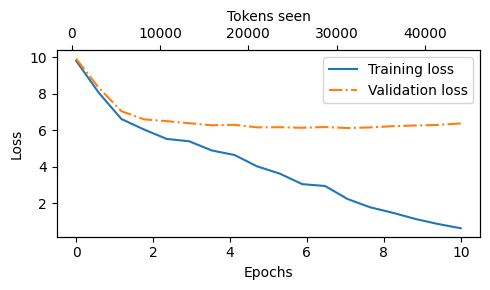

In [43]:
#train loss와 valid loss 시각화
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen,tokens_seen,train_losses,val_losses):
  fig,ax1=plt.subplots(figsize=(5,3))
  ax1.plot(epochs_seen,train_losses,label="Training loss")
  ax1.plot(
      epochs_seen,val_losses,linestyle="-.",label="Validation loss"
  )
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel("Loss")
  ax1.legend(loc="upper right")
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax2=ax1.twiny()
  ax2.plot(tokens_seen,train_losses,alpha=0)
  ax2.set_xlabel("Tokens seen")
  fig.tight_layout()
  plt.show()

epochs_tensor=torch.linspace(0,num_epochs,len(train_losses))
plot_losses(epochs_tensor,tokens_seen,train_losses,val_losses)

#무작위성을 제어하기 위한 디코딩 전략

In [ ]:
model.to("cpu")
model.eval()

In [45]:
#GPTModel의 객체를 generate_text_simple함수에 전달하여 한 번에 하나의 token씩 text를 생성한다.
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you",tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("출력 텍스트:\n",token_ids_to_text(token_ids,tokenizer))

출력 텍스트:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [46]:
#temperature scaling
vocab={
    "closer":0,
    "every":1,
    "effort":2,
    "forward":3,
    "inches":4,
    "moves":5,
    "pizza":6,
    "toward":7,
    "you":8,
}
inverse_vocab={v:k for k, v in vocab.items()}

In [47]:
#every effort moves you를 받고 다음과 같은 logits을 생성했다 가정
next_token_logits=torch.tensor(
    [4.51,0.89,-1.90,6.75,1.63,-1.62,-1.89,6.28,1.79]
)

In [48]:
#logits을 통해 다음에 생성해야 할 단어 예측
probas=torch.softmax(next_token_logits,dim=0)
next_token_id=torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [49]:
#확률적 샘플링 과정을 구현하기 위해 argmax를 multinomial()로 바꿀 수 있다.
torch.manual_seed(123)
next_token_id=torch.multinomial(probas,num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [50]:
#multinomial는 확률 점수에 비례해서 다음 token을 샘플링한다.
#그렇기에 대부분의 경우 확률이 가장 높은 token인 "forward"가 선택된다.
def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample=[torch.multinomial(probas,num_samples=1).item()
          for i in range(1_000)]
  sampled_ids=torch.bincount(torch.tensor(sample))
  for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [51]:
#temperature scaling은 logits을 0보다 큰 수로 나누는 방법이다.
def softmax_with_temperature(logits,temperature):
  scaled_logits=logits/temperature
  return torch.softmax(scaled_logits,dim=0)


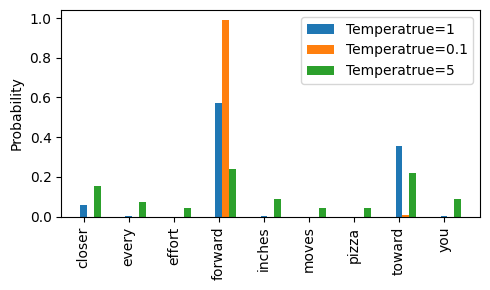

In [52]:
#temperature에 따른 분포의 차이
temperatures=[1,0.1,5]
scaled_probas=[softmax_with_temperature(next_token_logits,T)
                for T in temperatures]
x=torch.arange(len(vocab))
bar_width=0.15
fig,ax=plt.subplots(figsize=(5,3))
for i, T in enumerate(temperatures):
  rects=ax.bar(x+i*bar_width,scaled_probas[i],
               bar_width,label=f"Temperatrue={T}")

ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(),rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [53]:
#top-k sampling

top_k=3
top_logits,top_pos=torch.topk(next_token_logits,top_k)
print("탑-k 로짓:",top_logits)
print("탑-k 위치:",top_pos)

탑-k 로짓: tensor([6.7500, 6.2800, 4.5100])
탑-k 위치: tensor([3, 7, 0])


In [54]:
#나머지 token의 logit값을 음의 무한대로 지정한다.
new_logits=torch.where(
    #top k token 중 마지막 token보다 logit이 작은 token을 찾는다.
    condition=next_token_logits < top_logits[-1],
    #찾은 token의 logit을 -inf로 설정
    input=torch.tensor(float("-inf")),
    #이외 모든 token은 원래 logit값을 유지하도록 함
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [55]:
#softmax함수를 적용해 이를 다음 토큰 확률로 바꾼다.
topk_probas=torch.softmax(new_logits,dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [56]:
#generate_text_simple함수에 temperature scaling과 top-k sampling을 적용
def generate(model,idx,max_new_tokens,context_size,
             temperature=0.0,top_k=None,eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]
    #top k sampling 적용
    if top_k is not None:
      top_logits, _=torch.topk(logits,top_k)
      min_val=top_logits[:,-1]
      logits=torch.where(
          logits<min_val,
          torch.tensor(float("-inf")).to(logits.device),
          logits
      )
    #temperature scaling 적용
    if temperature>0.0:
      logits=logits/temperature
      probs=torch.softmax(logits,dim=-1)
      idx_next=torch.multinomial(probs,num_samples=1)
    #temperature scaling을 사용하지 않으면 이전처럼 다음 토큰을 선택한다.
    else:
      idx_next=torch.argmax(logits,dim=-1,keepdim=True)
    if idx_next == eos_id:
      break
    idx=torch.cat((idx,idx_next),dim=1)
  return idx

In [57]:
torch.manual_seed(123)
token_dis=generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you",tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("출력 텍스트:\n",token_ids_to_text(token_ids,tokenizer))

출력 텍스트:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




#pre-trained model 저장 및 로드

In [58]:
#model 저장
torch.save(model.state_dict(),"model.pth")


In [ ]:
#새로운 GPTModel 객체에 로드
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth",map_location=device))
model.eval()

In [60]:
#model과 optimizer의 state_dict 내용을 모두 저장
torch.save({
    "model_state_dict":model.state_dict(),
    "optimizer_state_dict":optimizer.state_dict(),},
           "model_and_optimizer.pth")

In [ ]:
#model과 optimizer의 상태 복원
checkpoint=torch.load("model_and_optimizer.pth",map_location=device)
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer=torch.optim.AdamW(model.parameters(),lr=5e-4,weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

#제공되는 GPT-2모델의 가중치 사용

In [62]:
!pip install tensorflow>=2.15.0 tqdm>=4.66

In [ ]:
import urllib.request
url=(
    "https://raw.githubusercontent.com/rickiepark/"
    "llm-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename=url.split('/')[-1]
urllib.request.urlretrieve(url,filename)

In [ ]:
from gpt_download import download_and_load_gpt2
settings, params=download_and_load_gpt2(
    model_size="124M",models_dir="gpt2"
)

In [65]:
print("설정:",settings)
print("파라미터 딕셔너리 키:",params.keys())

설정: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
파라미터 딕셔너리 키: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [66]:
print(params["wte"])
print("토큰 임베딩 가중치 텐서의 차원:",params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
토큰 임베딩 가중치 텐서의 차원: (50257, 768)


In [67]:
model_configs={
    "gpt2-small (124M)":{"emb_dim":768,"n_layers":12,"n_heads":12},
    "gpt2-medium (355M)":{"emb_dim":1024,"n_layers":24,"n_heads":16},
    "gpt2-large (774M)":{"emb_dim":1280,"n_layers":36,"n_heads":20},
    "gpt2-xl (1558M)":{"emb_dim":1600,"n_layers":48,"n_heads":25},
}

In [68]:
#가장 작은 모델인 gpt2-small (124M)을 로드
model_name="gpt2-small (124M)"
NEW_CONFIG=GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [69]:
NEW_CONFIG.update({"context_length":1024})

In [70]:
NEW_CONFIG.update({"qkv_bias":True})

In [ ]:
gpt=GPTModel(NEW_CONFIG)
gpt.eval()

In [72]:
#GPTModel의 객체는 랜덤한 가중치로 초기화되었는데,
#이를 params dictornary에 있는 가중치로 바꾼다.
def assign(left,right):
  if left.shape != right.shape:
    raise ValueError(f"크기가 다릅니다. left: {left.shape}, "
                      "right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))

In [73]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device);

In [ ]:
load_weights_into_gpt(gpt,params)
gpt.to(device)

In [75]:
torch.manual_seed(123)
token_ids=generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("출력 텍스트:\n",token_ids_to_text(token_ids,tokenizer))

출력 텍스트:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle
